In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.interpolate import griddata
from matplotlib.colors import LogNorm


# --------------------------------------------
# PROJECT FOLDERS
# --------------------------------------------

project_dir = Path(".")

dgps_dir = project_dir / "DGPS data"
ert_dir = project_dir / "ERT data"


# --------------------------------------------
# EXACT FILENAMES
# --------------------------------------------

dgps_file = dgps_dir / "onyx ert 092726.csv"

dd1_file = ert_dir / "DipoleDipole_1-2023-03-07-214954.dat"
dd2_file = ert_dir / "DipoleDipole_2-2023-03-07-214927.dat"

gradient1_file = ert_dir / "Gradient_XL_1-2023-03-07-214625.dat"
gradient2_file = ert_dir / "Gradient_XL_1-2023-03-07-214846.dat"


print("DGPS:", dgps_file.exists())
print("DD1:", dd1_file.exists())
print("DD2:", dd2_file.exists())
print("Gradient 1:", gradient1_file.exists())
print("Gradient 2:", gradient2_file.exists())

DGPS: True
DD1: True
DD2: True
Gradient 1: True
Gradient 2: True


In [4]:
dgps = pd.read_csv(dgps_file)

display(
    dgps[
        [
            "Name",
            "Longitude",
            "Latitude",
            "Ellipsoidal height",
            "Elevation RMS"
        ]
    ].head(10)
)

,Name,Longitude,Latitude,Ellipsoidal height,Elevation RMS
0,base,-106.836025,40.478782,2112.999,0.300
1,base1,-106.836009,40.478783,2114.972,NaN
2,ert1,-106.835705,40.479164,2108.275,0.254
3,ert2,-106.835701,40.479153,2108.226,0.245
4,ert3,-106.835693,40.479137,2107.967,0.263
5,ert4,-106.835687,40.479127,2108.414,0.254
6,ert5,-106.835682,40.479112,2108.764,0.232
7,ert6,-106.835674,40.479098,2109.277,0.228
8,ert7,-106.835669,40.479086,2109.051,0.220
9,ert8,-106.835660,40.479072,2109.368,0.248


cut base 1 ^

In [5]:
def build_dgps_profile(dgps, line=1, electrode_spacing=1.5):

    df = dgps.copy()

    if line == 1:

        mask = df["Name"].astype(str).str.fullmatch(
            r"ert\d+",
            na=False
        )

        profile = df.loc[mask].copy()

        profile["electrode"] = (
            profile["Name"]
            .str.extract(r"ert(\d+)")[0]
            .astype(int)
        )


    elif line == 2:

        mask = df["Name"].astype(str).str.fullmatch(
            r"2ert\d+",
            na=False
        )

        profile = df.loc[mask].copy()

        profile["electrode"] = (
            profile["Name"]
            .str.extract(r"2ert(\d+)")[0]
            .astype(int)
        )

    else:

        raise ValueError("line must be 1 or 2")


    # Elevation from DGPS
    profile["elevation_m"] = pd.to_numeric(
        profile["Ellipsoidal height"],
        errors="coerce"
    )


    # Sort by electrode
    profile = profile.sort_values("electrode")


    # ERT electrodes are spaced exactly 1.5 m apart
    profile["distance_m"] = (
        profile["electrode"] - 1
    ) * electrode_spacing


    return profile

In [6]:
dgps1 = build_dgps_profile(
    dgps,
    line=1
)

dgps2 = build_dgps_profile(
    dgps,
    line=2
)

display(dgps1.head())

,Name,Code,Code description,Easting,Northing,Elevation,Description,Longitude,Latitude,Ellipsoidal height,...,GLONASS Satellites,Galileo Satellites,BeiDou Satellites,QZSS Satellites,Device type,Device serial number,Author,electrode,elevation_m,distance_m
2,ert1,NaN,NaN,NaN,NaN,NaN,NaN,-106.835705,40.479164,2108.275,...,NaN,NaN,NaN,NaN,Reach RS2,8243D61ABE0C1461,NaN,1,2108.275,0.0
3,ert2,NaN,NaN,NaN,NaN,NaN,NaN,-106.835701,40.479153,2108.226,...,NaN,NaN,NaN,NaN,Reach RS2,8243D61ABE0C1461,NaN,2,2108.226,1.5
4,ert3,NaN,NaN,NaN,NaN,NaN,NaN,-106.835693,40.479137,2107.967,...,NaN,NaN,NaN,NaN,Reach RS2,8243D61ABE0C1461,NaN,3,2107.967,3.0
5,ert4,NaN,NaN,NaN,NaN,NaN,NaN,-106.835687,40.479127,2108.414,...,NaN,NaN,NaN,NaN,Reach RS2,8243D61ABE0C1461,NaN,4,2108.414,4.5
6,ert5,NaN,NaN,NaN,NaN,NaN,NaN,-106.835682,40.479112,2108.764,...,NaN,NaN,NaN,NaN,Reach RS2,8243D61ABE0C1461,NaN,5,2108.764,6.0


In [18]:
# Fix the second ERT line naming error

# First shift the ORIGINAL 2ert5 through 2ert15 forward by one
for i in range(15, 4, -1):
    dgps.loc[dgps["Name"] == f"2ert{i}", "Name"] = f"2ert{i+1}"

# Then rename the misplaced point
dgps.loc[
    dgps["Name"] == "2ert_shouldbe5",
    "Name"
] = "2ert5"

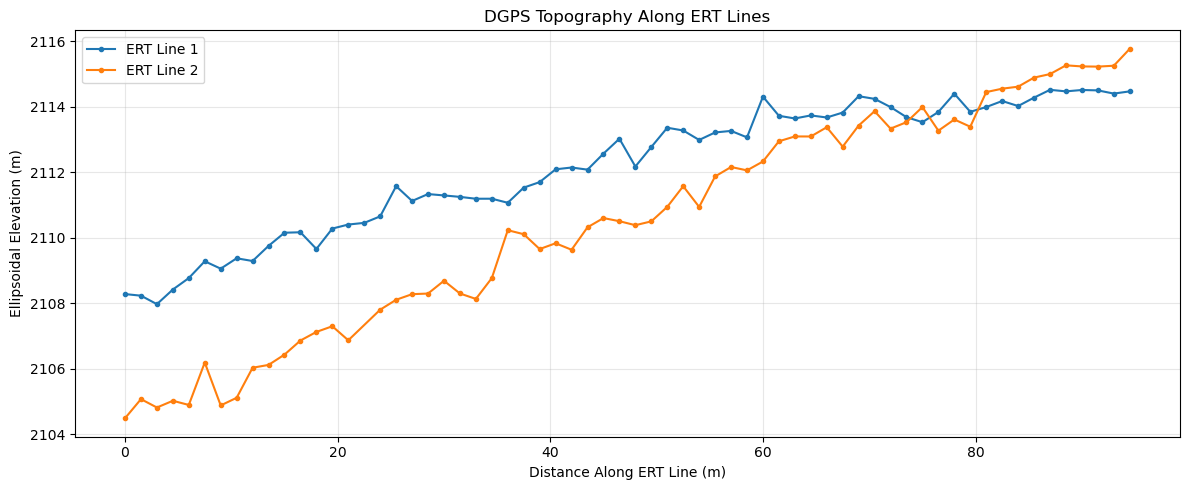

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    dgps1["distance_m"],
    dgps1["elevation_m"],
    marker="o",
    markersize=3,
    label="ERT Line 1"
)

ax.plot(
    dgps2["distance_m"],
    dgps2["elevation_m"],
    marker="o",
    markersize=3,
    label="ERT Line 2"
)

ax.set_xlabel("Distance Along ERT Line (m)")
ax.set_ylabel("Ellipsoidal Elevation (m)")

ax.set_title("DGPS Topography Along ERT Lines")

ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [9]:
def read_abem_dat(filepath):

    with open(
        filepath,
        "r",
        encoding="utf-8",
        errors="replace"
    ) as f:

        lines = [
            line.strip()
            for line in f.readlines()
        ]


    # ---------------------------------
    # HEADER
    # ---------------------------------

    title = lines[0]

    electrode_spacing = float(
        lines[1]
    )

    measurement_type = int(
        lines[5]
    )

    n_measurements = int(
        lines[6]
    )


    # ---------------------------------
    # READ MEASUREMENTS
    # ---------------------------------

    rows = []

    for line in lines[
        9 : 9 + n_measurements
    ]:

        values = [
            float(v)
            for v in line.split()
        ]

        rows.append(values)


    columns = [
        "n_elec",
        "A_x",
        "A_z",
        "B_x",
        "B_z",
        "M_x",
        "M_z",
        "N_x",
        "N_z",
        "resistance"
    ]


    ert = pd.DataFrame(
        rows,
        columns=columns
    )


    ert.attrs["title"] = title

    ert.attrs["electrode_spacing"] = electrode_spacing

    ert.attrs["measurement_type"] = measurement_type


    return ert

In [11]:
dd1 = read_abem_dat(dd1_file)
dd2 = read_abem_dat(dd2_file)

gradient_05m = read_abem_dat(gradient1_file)
gradient_15m = read_abem_dat(gradient2_file)

print(dd1.attrs)
display(dd1.head())

{'title': 'Project25 DipoleDipole_1', 'electrode_spacing': 1.5, 'measurement_type': 1}


,n_elec,A_x,A_z,B_x,B_z,M_x,M_z,N_x,N_z,resistance
0,4.0,4.5,0.0,3.0,0.0,0.0,0.0,1.5,0.0,1.497830
1,4.0,6.0,0.0,4.5,0.0,0.0,0.0,1.5,0.0,0.247843
2,4.0,6.0,0.0,4.5,0.0,1.5,0.0,3.0,0.0,1.757610
3,4.0,7.5,0.0,6.0,0.0,0.0,0.0,1.5,0.0,0.092081
4,4.0,9.0,0.0,6.0,0.0,0.0,0.0,3.0,0.0,0.414660


In [12]:
def calculate_apparent_resistivity(ert):

    ert = ert.copy()


    def r(x1, z1, x2, z2):

        return np.sqrt(
            (x1 - x2)**2
            +
            (z1 - z2)**2
        )


    r_AM = r(
        ert["A_x"],
        ert["A_z"],
        ert["M_x"],
        ert["M_z"]
    )

    r_AN = r(
        ert["A_x"],
        ert["A_z"],
        ert["N_x"],
        ert["N_z"]
    )

    r_BM = r(
        ert["B_x"],
        ert["B_z"],
        ert["M_x"],
        ert["M_z"]
    )

    r_BN = r(
        ert["B_x"],
        ert["B_z"],
        ert["N_x"],
        ert["N_z"]
    )


    denominator = (
        1 / r_AM
        - 1 / r_AN
        - 1 / r_BM
        + 1 / r_BN
    )


    ert["K"] = (
        2 * np.pi
        /
        denominator
    )


    ert["apparent_resistivity"] = (
        ert["K"]
        *
        ert["resistance"]
    )


    # Horizontal center of measurement

    AB_mid = (
        ert["A_x"]
        +
        ert["B_x"]
    ) / 2


    MN_mid = (
        ert["M_x"]
        +
        ert["N_x"]
    ) / 2


    ert["distance_m"] = (
        AB_mid
        +
        MN_mid
    ) / 2


    # Approximate pseudodepth

    ert["pseudo_depth_m"] = (
        np.abs(
            AB_mid
            -
            MN_mid
        )
        / 2
    )


    return ert

In [13]:
dd1 = calculate_apparent_resistivity(dd1)

dd2 = calculate_apparent_resistivity(dd2)

In [14]:
dd1["surface_elevation_m"] = np.interp(
    dd1["distance_m"],
    dgps1["distance_m"],
    dgps1["elevation_m"]
)

In [15]:
dd1["ert_elevation_m"] = (
    dd1["surface_elevation_m"]
    -
    dd1["pseudo_depth_m"]
)

In [16]:
display(
    dd1[
        [
            "distance_m",
            "pseudo_depth_m",
            "surface_elevation_m",
            "ert_elevation_m",
            "apparent_resistivity"
        ]
    ].head()
)

,distance_m,pseudo_depth_m,surface_elevation_m,ert_elevation_m,apparent_resistivity
0,2.25,1.50,2108.0965,2106.5965,42.350146
1,3.00,2.25,2107.9670,2105.7170,28.030383
2,3.75,1.50,2108.1905,2106.6905,49.695252
3,3.75,3.00,2108.1905,2105.1905,26.035318
4,4.50,3.00,2108.4140,2105.4140,23.448471


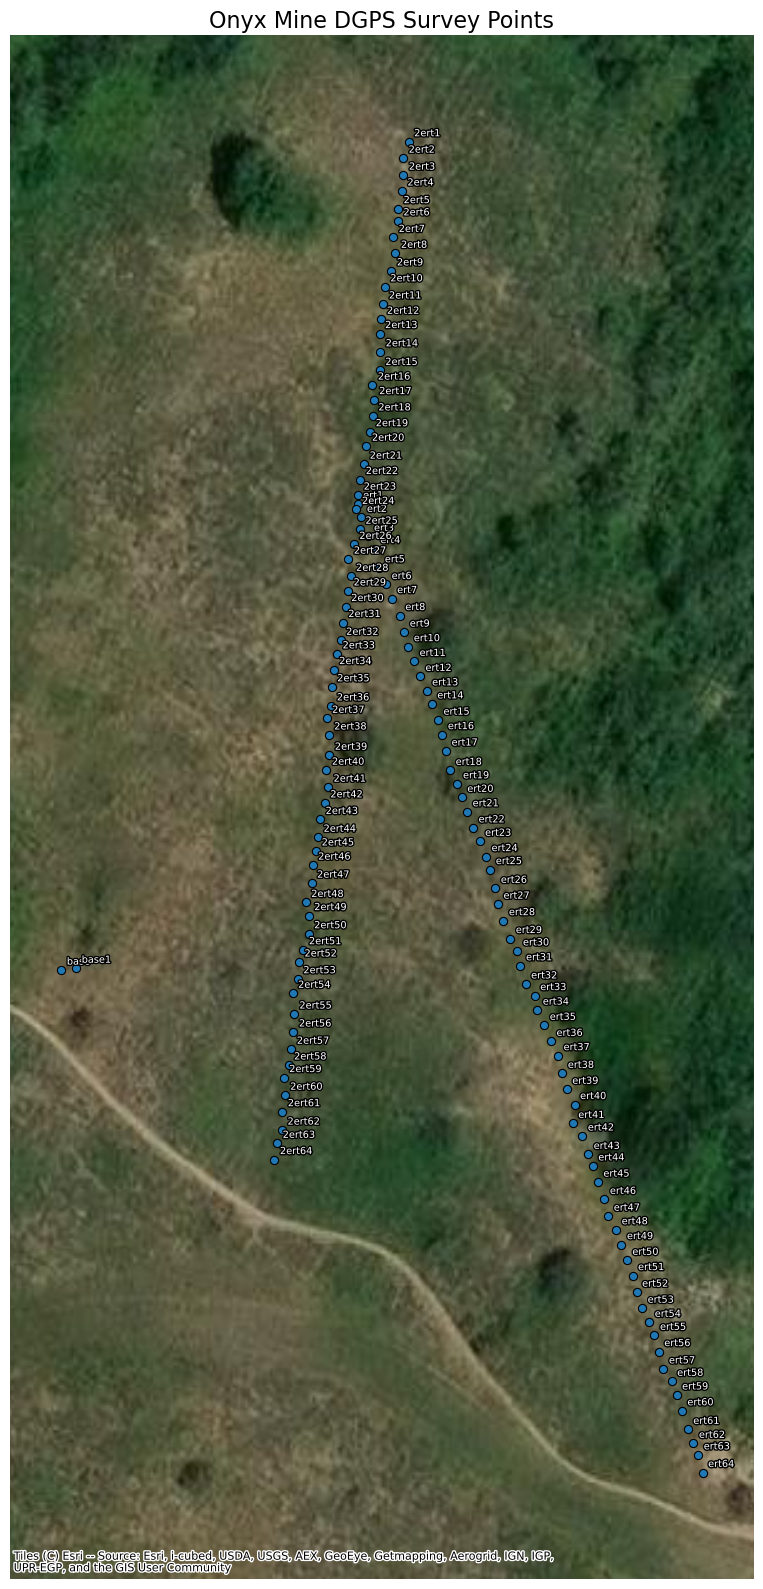

In [19]:
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe


# ----------------------------------------------------
# PREPARE DGPS DATA
# ----------------------------------------------------

# Keep points that actually have coordinates
dgps_map = dgps.dropna(
    subset=["Longitude", "Latitude"]
).copy()

# Make sure coordinates are numeric
dgps_map["Longitude"] = pd.to_numeric(
    dgps_map["Longitude"],
    errors="coerce"
)

dgps_map["Latitude"] = pd.to_numeric(
    dgps_map["Latitude"],
    errors="coerce"
)

dgps_map = dgps_map.dropna(
    subset=["Longitude", "Latitude"]
)


# ----------------------------------------------------
# CREATE GEODATAFRAME
# ----------------------------------------------------

gdf_dgps = gpd.GeoDataFrame(
    dgps_map,
    geometry=gpd.points_from_xy(
        dgps_map["Longitude"],
        dgps_map["Latitude"]
    ),
    crs="EPSG:4326"
)

# Convert to Web Mercator for satellite basemap
gdf_dgps = gdf_dgps.to_crs(
    epsg=3857
)


# ----------------------------------------------------
# PLOT
# ----------------------------------------------------

fig, ax = plt.subplots(
    figsize=(16, 16)
)


# Plot every DGPS point
gdf_dgps.plot(
    ax=ax,
    marker="o",
    markersize=35,
    edgecolor="black",
    linewidth=0.8,
    zorder=3
)


# ----------------------------------------------------
# LABEL EVERY POINT USING CSV "Name"
# ----------------------------------------------------

for _, row in gdf_dgps.iterrows():

    x = row.geometry.x
    y = row.geometry.y

    label = str(row["Name"])

    text = ax.annotate(
        label,
        xy=(x, y),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=7,
        color="white",
        zorder=4
    )

    # Black outline around white text so labels
    # remain readable over satellite imagery
    text.set_path_effects([
        pe.Stroke(
            linewidth=2,
            foreground="black"
        ),
        pe.Normal()
    ])


# ----------------------------------------------------
# ADD A LITTLE MAP BUFFER
# ----------------------------------------------------

xmin, ymin, xmax, ymax = gdf_dgps.total_bounds

x_buffer = (xmax - xmin) * 0.08
y_buffer = (ymax - ymin) * 0.08

ax.set_xlim(
    xmin - x_buffer,
    xmax + x_buffer
)

ax.set_ylim(
    ymin - y_buffer,
    ymax + y_buffer
)


# ----------------------------------------------------
# SATELLITE BASEMAP
# ----------------------------------------------------

ctx.add_basemap(
    ax,
    source=ctx.providers.Esri.WorldImagery,
    zoom=19
)


# ----------------------------------------------------
# FORMATTING
# ----------------------------------------------------

ax.set_title(
    "Onyx Mine DGPS Survey Points",
    fontsize=16
)

ax.set_xlabel("")
ax.set_ylabel("")

ax.set_axis_off()

plt.tight_layout()

plt.show()

In [20]:
print("Dipole-Dipole Line 1")
print(dd1.attrs)
print("Shape:", dd1.shape)
display(dd1.head())

print("\nDipole-Dipole Line 2")
print(dd2.attrs)
print("Shape:", dd2.shape)
display(dd2.head())

Dipole-Dipole Line 1
{'title': 'Project25 DipoleDipole_1', 'electrode_spacing': 1.5, 'measurement_type': 1}
Shape: (1980, 16)


,n_elec,A_x,A_z,B_x,B_z,M_x,M_z,N_x,N_z,resistance,K,apparent_resistivity,distance_m,pseudo_depth_m,surface_elevation_m,ert_elevation_m
0,4.0,4.5,0.0,3.0,0.0,0.0,0.0,1.5,0.0,1.497830,28.274334,42.350146,2.25,1.50,2108.0965,2106.5965
1,4.0,6.0,0.0,4.5,0.0,0.0,0.0,1.5,0.0,0.247843,113.097336,28.030383,3.00,2.25,2107.9670,2105.7170
2,4.0,6.0,0.0,4.5,0.0,1.5,0.0,3.0,0.0,1.757610,28.274334,49.695252,3.75,1.50,2108.1905,2106.6905
3,4.0,7.5,0.0,6.0,0.0,0.0,0.0,1.5,0.0,0.092081,282.743339,26.035318,3.75,3.00,2108.1905,2105.1905
4,4.0,9.0,0.0,6.0,0.0,0.0,0.0,3.0,0.0,0.414660,56.548668,23.448471,4.50,3.00,2108.4140,2105.4140



Dipole-Dipole Line 2
{'title': 'Project25 DipoleDipole_2', 'electrode_spacing': 1.5, 'measurement_type': 1}
Shape: (1980, 14)


,n_elec,A_x,A_z,B_x,B_z,M_x,M_z,N_x,N_z,resistance,K,apparent_resistivity,distance_m,pseudo_depth_m
0,4.0,4.5,0.0,3.0,0.0,0.0,0.0,1.5,0.0,4.792730,28.274334,135.511248,2.25,1.50
1,4.0,6.0,0.0,4.5,0.0,0.0,0.0,1.5,0.0,0.453241,113.097336,51.260349,3.00,2.25
2,4.0,6.0,0.0,4.5,0.0,1.5,0.0,3.0,0.0,4.878790,28.274334,137.944537,3.75,1.50
3,4.0,7.5,0.0,6.0,0.0,0.0,0.0,1.5,0.0,0.110217,282.743339,31.163123,3.75,3.00
4,4.0,9.0,0.0,6.0,0.0,0.0,0.0,3.0,0.0,0.671809,56.548668,37.989904,4.50,3.00


In [21]:
for name, ert in [
    ("DD Line 1", dd1),
    ("DD Line 2", dd2)
]:
    print(name)
    print("A x range:", ert["A_x"].min(), "to", ert["A_x"].max())
    print("B x range:", ert["B_x"].min(), "to", ert["B_x"].max())
    print("M x range:", ert["M_x"].min(), "to", ert["M_x"].max())
    print("N x range:", ert["N_x"].min(), "to", ert["N_x"].max())
    print("Resistance range:", ert["resistance"].min(), "to", ert["resistance"].max())
    print()

DD Line 1
A x range: 4.5 to 94.5
B x range: 3.0 to 93.0
M x range: 0.0 to 90.0
N x range: 1.5 to 91.5
Resistance range: 0.00124613 to 3.34977

DD Line 2
A x range: 4.5 to 94.5
B x range: 3.0 to 93.0
M x range: 0.0 to 90.0
N x range: 1.5 to 91.5
Resistance range: 0.00193907 to 5.50781



In [22]:
display(
    dd1[
        [
            "A_x",
            "B_x",
            "M_x",
            "N_x",
            "resistance",
            "K",
            "apparent_resistivity",
            "distance_m",
            "pseudo_depth_m"
        ]
    ].head(20)
)

,A_x,B_x,M_x,N_x,resistance,K,apparent_resistivity,distance_m,pseudo_depth_m
0,4.5,3.0,0.0,1.5,1.497830,28.274334,42.350146,2.25,1.50
1,6.0,4.5,0.0,1.5,0.247843,113.097336,28.030383,3.00,2.25
2,6.0,4.5,1.5,3.0,1.757610,28.274334,49.695252,3.75,1.50
3,7.5,6.0,0.0,1.5,0.092081,282.743339,26.035318,3.75,3.00
4,9.0,6.0,0.0,3.0,0.414660,56.548668,23.448471,4.50,3.00
5,7.5,6.0,1.5,3.0,0.210088,113.097336,23.760393,4.50,2.25
6,9.0,7.5,0.0,1.5,0.041610,565.486678,23.529844,4.50,3.75
7,10.5,9.0,0.0,1.5,0.025889,989.601686,25.619501,5.25,4.50
8,7.5,6.0,3.0,4.5,1.185520,28.274334,33.519788,5.25,1.50
9,9.0,7.5,1.5,3.0,0.070932,282.743339,20.055494,5.25,3.00


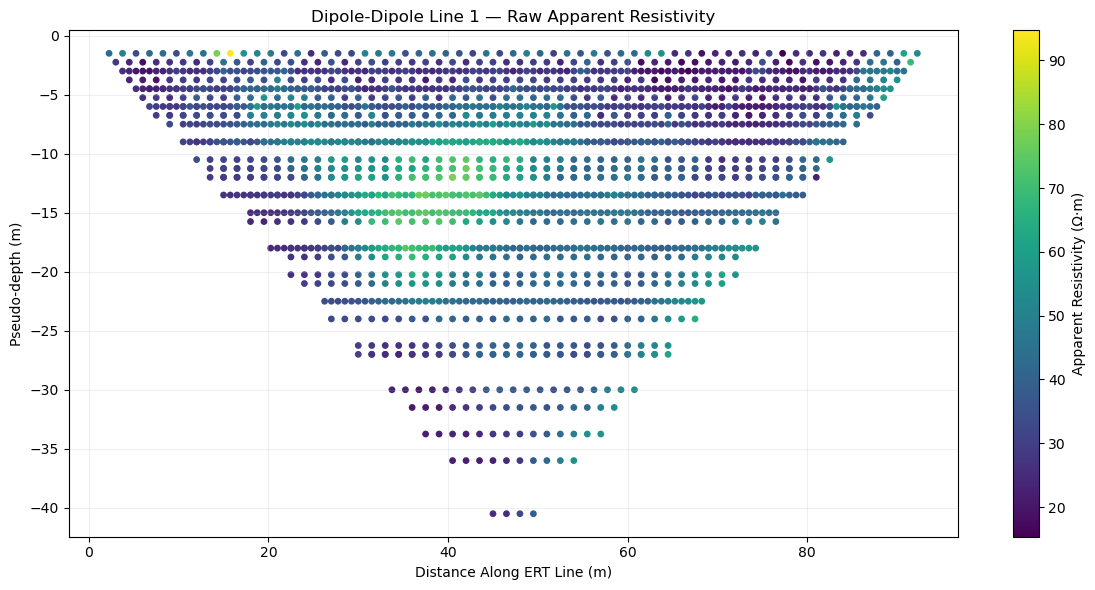

In [23]:
fig, ax = plt.subplots(figsize=(12, 6))

sc = ax.scatter(
    dd1["distance_m"],
    -dd1["pseudo_depth_m"],
    c=dd1["apparent_resistivity"],
    s=15
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Apparent Resistivity (Ω·m)")

ax.set_xlabel("Distance Along ERT Line (m)")
ax.set_ylabel("Pseudo-depth (m)")
ax.set_title("Dipole-Dipole Line 1 — Raw Apparent Resistivity")

ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [24]:
def build_dgps_profile(dgps, line=1, electrode_spacing=1.5):

    df = dgps.copy()

    if line == 1:

        mask = df["Name"].astype(str).str.fullmatch(
            r"ert\d+",
            na=False
        )

        profile = df.loc[mask].copy()

        profile["dgps_point"] = (
            profile["Name"]
            .str.extract(r"ert(\d+)")[0]
            .astype(int)
        )


    elif line == 2:

        mask = df["Name"].astype(str).str.fullmatch(
            r"2ert\d+",
            na=False
        )

        profile = df.loc[mask].copy()

        profile["dgps_point"] = (
            profile["Name"]
            .str.extract(r"2ert(\d+)")[0]
            .astype(int)
        )

    else:

        raise ValueError("line must be 1 or 2")


    # ----------------------------------------
    # REVERSE DGPS NUMBERING TO MATCH ERT
    #
    # DGPS 1  = electrode 64
    # DGPS 64 = electrode 1
    # ----------------------------------------

    profile["electrode"] = (
        65 - profile["dgps_point"]
    )


    # DGPS elevation
    profile["elevation_m"] = pd.to_numeric(
        profile["Ellipsoidal height"],
        errors="coerce"
    )


    # ----------------------------------------
    # ERT coordinate
    #
    # Electrode 1 = x = 0 m
    # Electrode 64 = x = 94.5 m
    # ----------------------------------------

    profile["distance_m"] = (
        profile["electrode"] - 1
    ) * electrode_spacing


    # Sort in same direction as ERT dataset
    profile = profile.sort_values(
        "electrode"
    ).reset_index(drop=True)


    return profile

In [25]:
# Interpolate DGPS surface elevation at every ERT measurement location

dd1["surface_elevation_m"] = np.interp(
    dd1["distance_m"],
    dgps1["distance_m"],
    dgps1["elevation_m"]
)

# Convert pseudo-depth into actual elevation
dd1["ert_elevation_m"] = (
    dd1["surface_elevation_m"]
    - dd1["pseudo_depth_m"]
)

In [26]:
display(
    dd1[
        [
            "distance_m",
            "pseudo_depth_m",
            "surface_elevation_m",
            "ert_elevation_m",
            "apparent_resistivity"
        ]
    ].head(10)
)

,distance_m,pseudo_depth_m,surface_elevation_m,ert_elevation_m,apparent_resistivity
0,2.25,1.50,2108.0965,2106.5965,42.350146
1,3.00,2.25,2107.9670,2105.7170,28.030383
2,3.75,1.50,2108.1905,2106.6905,49.695252
3,3.75,3.00,2108.1905,2105.1905,26.035318
4,4.50,3.00,2108.4140,2105.4140,23.448471
5,4.50,2.25,2108.4140,2106.1640,23.760393
6,4.50,3.75,2108.4140,2104.6640,23.529844
7,5.25,4.50,2108.5890,2104.0890,25.619501
8,5.25,1.50,2108.5890,2107.0890,33.519788
9,5.25,3.00,2108.5890,2105.5890,20.055494


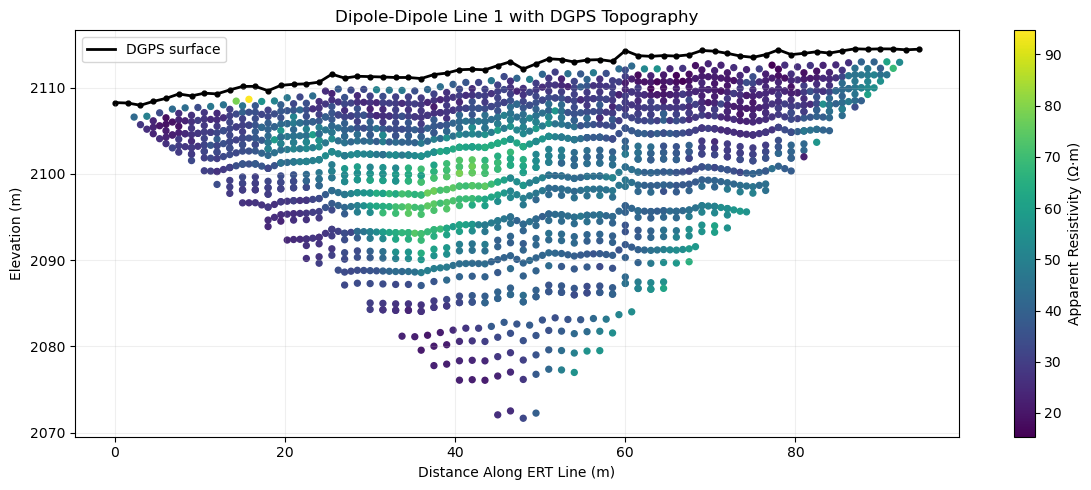

In [28]:
fig, ax = plt.subplots(figsize=(12, 5))

sc = ax.scatter(
    dd1["distance_m"],
    dd1["ert_elevation_m"],
    c=dd1["apparent_resistivity"],
    s=18
)

# DGPS ground surface
ax.plot(
    dgps1["distance_m"],
    dgps1["elevation_m"],
    color="black",
    linewidth=2,
    label="DGPS surface"
)

ax.scatter(
    dgps1["distance_m"],
    dgps1["elevation_m"],
    color="black",
    s=12
)

# Colorbar
cbar = plt.colorbar(sc, ax=ax)

cbar.set_label(
    "Apparent Resistivity (Ω·m)"
)

ax.set_xlabel(
    "Distance Along ERT Line (m)"
)

ax.set_ylabel(
    "Elevation (m)"
)

ax.set_title(
    "Dipole-Dipole Line 1 with DGPS Topography"
)

ax.legend()

ax.grid(
    alpha=0.2
)

plt.tight_layout()

plt.show()

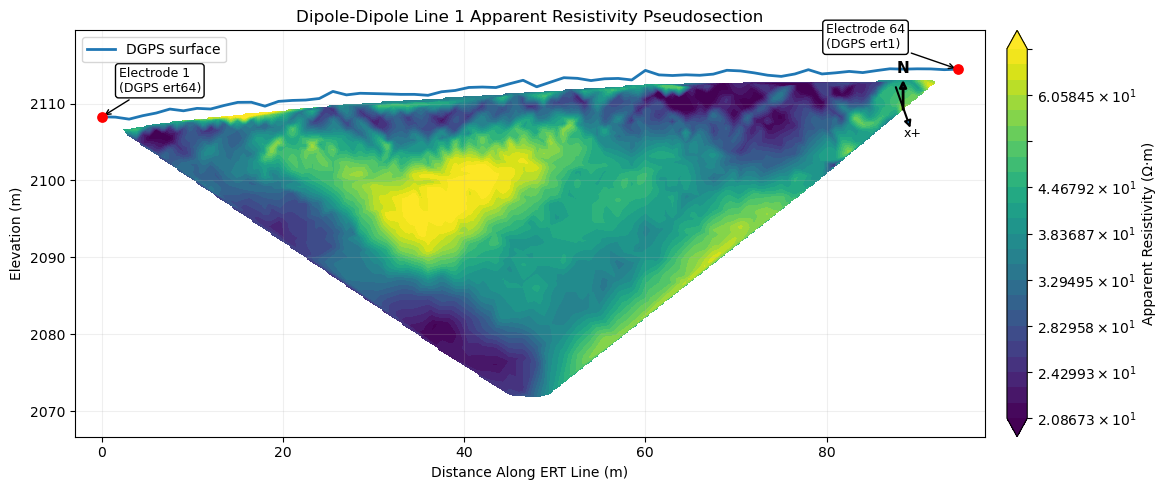

In [56]:
# -------------------------------------------
# Continuous ERT pseudosection with DGPS topography
# -------------------------------------------

from scipy.interpolate import griddata
from matplotlib.colors import LogNorm
import numpy as np
import matplotlib.pyplot as plt


# Keep only valid positive resistivity values
plot_df = dd1.copy()

plot_df = plot_df[
    np.isfinite(plot_df["apparent_resistivity"]) &
    np.isfinite(plot_df["distance_m"]) &
    np.isfinite(plot_df["ert_elevation_m"]) &
    (plot_df["apparent_resistivity"] > 0)
].copy()


# -------------------------------------------
# Build interpolation grid
# -------------------------------------------

x_min = dgps1["distance_m"].min()
x_max = dgps1["distance_m"].max()

y_min = plot_df["ert_elevation_m"].min()
y_max = dgps1["elevation_m"].max()

xi = np.linspace(x_min, x_max, 400)
yi = np.linspace(y_min, y_max, 250)

XI, YI = np.meshgrid(xi, yi)


# Interpolate apparent resistivity onto grid
ZI = griddata(
    (plot_df["distance_m"], plot_df["ert_elevation_m"]),
    plot_df["apparent_resistivity"],
    (XI, YI),
    method="linear"
)


# -------------------------------------------
# Mask everything above the DGPS surface
# -------------------------------------------

surface_elev = np.interp(
    xi,
    dgps1["distance_m"],
    dgps1["elevation_m"]
)

for j in range(len(xi)):
    ZI[YI[:, j] > surface_elev[j], j] = np.nan


# -------------------------------------------
# Choose contour levels
# -------------------------------------------

vmin = np.nanpercentile(plot_df["apparent_resistivity"], 2)
vmax = np.nanpercentile(plot_df["apparent_resistivity"], 98)

levels = np.geomspace(vmin, vmax, 25)


# -------------------------------------------
# Plot
# -------------------------------------------

fig, ax = plt.subplots(figsize=(12, 5))
# -------------------------------------------
# Add orientation / north indicator
# -------------------------------------------

# Small inset compass
compass = ax.inset_axes(
    [0.86, 0.72, 0.10, 0.18]
)

compass.set_xlim(-1.2, 1.2)
compass.set_ylim(-1.2, 1.2)
compass.set_aspect("equal")
compass.axis("off")


# NORTH ARROW
compass.annotate(
    "",
    xy=(0, 1),
    xytext=(0, -0.15),
    arrowprops=dict(
        arrowstyle="-|>",
        linewidth=2
    )
)

compass.text(
    0,
    1.05,
    "N",
    ha="center",
    va="bottom",
    fontsize=11,
    fontweight="bold"
)


# -------------------------------------------
# ERT line direction
# -------------------------------------------

# Convert bearing to plotting angle
theta = np.radians(90 - bearing)

dx = 0.8 * np.cos(theta)
dy = 0.8 * np.sin(theta)

compass.annotate(
    "",
    xy=(dx, dy),
    xytext=(-dx, -dy),
    arrowprops=dict(
        arrowstyle="-|>",
        linewidth=1.5
    )
)

compass.text(
    dx * 1.15,
    dy * 1.15,
    "x+",
    ha="center",
    va="center",
    fontsize=9
)
cf = ax.contourf(
    XI,
    YI,
    ZI,
    levels=levels,
    norm=LogNorm(vmin=vmin, vmax=vmax),
    extend="both"
)

# DGPS surface
ax.plot(
    dgps1["distance_m"],
    dgps1["elevation_m"],
    linewidth=2,
    label="DGPS surface"
)



cbar = plt.colorbar(cf, ax=ax, pad=0.02)
cbar.set_label("Apparent Resistivity (Ω·m)")

ax.set_xlabel("Distance Along ERT Line (m)")
ax.set_ylabel("Elevation (m)")
ax.set_title("Dipole-Dipole Line 1 Apparent Resistivity Pseudosection")
ax.legend()
ax.grid(alpha=0.2)

# -------------------------------------------
# Label first and last electrodes
# -------------------------------------------

# First electrode (x = 0 m)
x1 = dgps1["distance_m"].iloc[0]
y1 = dgps1["elevation_m"].iloc[0]

ax.scatter(x1, y1, s=45, color="red", zorder=5)

ax.annotate(
    "Electrode 1\n(DGPS ert64)",
    xy=(x1, y1),
    xytext=(12, 18),
    textcoords="offset points",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="black"),
    arrowprops=dict(arrowstyle="->")
)


# Last electrode (x = 94.5 m)
x2 = dgps1["distance_m"].iloc[-1]
y2 = dgps1["elevation_m"].iloc[-1]

ax.scatter(x2, y2, s=45, color="red", zorder=5)

ax.annotate(
    "Electrode 64\n(DGPS ert1)",
    xy=(x2, y2),
    xytext=(-95, 15),
    textcoords="offset points",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="black"),
    arrowprops=dict(arrowstyle="->")
)

# -------------------------------------------
# Add a little vertical space around the plot
# -------------------------------------------

current_ymin, current_ymax = ax.get_ylim()

ax.set_ylim(
    current_ymin - 5,
    current_ymax + 5
)

ax.set_xlim(
    -3,
    97.5
)

plt.tight_layout()
plt.savefig(
    "DipoleDipole_Line1_Pseudosection.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [31]:
# -------------------------------------------
# Calculate ERT line bearing
# x = 0 m   -> ert64
# x = 94.5m -> ert1
# -------------------------------------------

lat1 = np.radians(dgps1.iloc[0]["Latitude"])
lon1 = np.radians(dgps1.iloc[0]["Longitude"])

lat2 = np.radians(dgps1.iloc[-1]["Latitude"])
lon2 = np.radians(dgps1.iloc[-1]["Longitude"])

dlon = lon2 - lon1

x_bearing = np.sin(dlon) * np.cos(lat2)

y_bearing = (
    np.cos(lat1) * np.sin(lat2)
    - np.sin(lat1) * np.cos(lat2) * np.cos(dlon)
)

bearing = (
    np.degrees(
        np.arctan2(x_bearing, y_bearing)
    )
    + 360
) % 360

print(f"ERT line bearing: {bearing:.1f}°")

ERT line bearing: 160.4°


In [32]:
# -------------------------------------------
# Add orientation / north indicator
# -------------------------------------------

# Small inset compass
compass = ax.inset_axes(
    [0.86, 0.72, 0.10, 0.18]
)

compass.set_xlim(-1.2, 1.2)
compass.set_ylim(-1.2, 1.2)
compass.set_aspect("equal")
compass.axis("off")


# NORTH ARROW
compass.annotate(
    "",
    xy=(0, 1),
    xytext=(0, -0.15),
    arrowprops=dict(
        arrowstyle="-|>",
        linewidth=2
    )
)

compass.text(
    0,
    1.05,
    "N",
    ha="center",
    va="bottom",
    fontsize=11,
    fontweight="bold"
)


# -------------------------------------------
# ERT line direction
# -------------------------------------------

# Convert bearing to plotting angle
theta = np.radians(90 - bearing)

dx = 0.8 * np.cos(theta)
dy = 0.8 * np.sin(theta)

compass.annotate(
    "",
    xy=(dx, dy),
    xytext=(-dx, -dy),
    arrowprops=dict(
        arrowstyle="-|>",
        linewidth=1.5
    )
)

compass.text(
    dx * 1.15,
    dy * 1.15,
    "x+",
    ha="center",
    va="center",
    fontsize=9
)

Text(0.3086357908832328, -0.8666856111565955, 'x+')

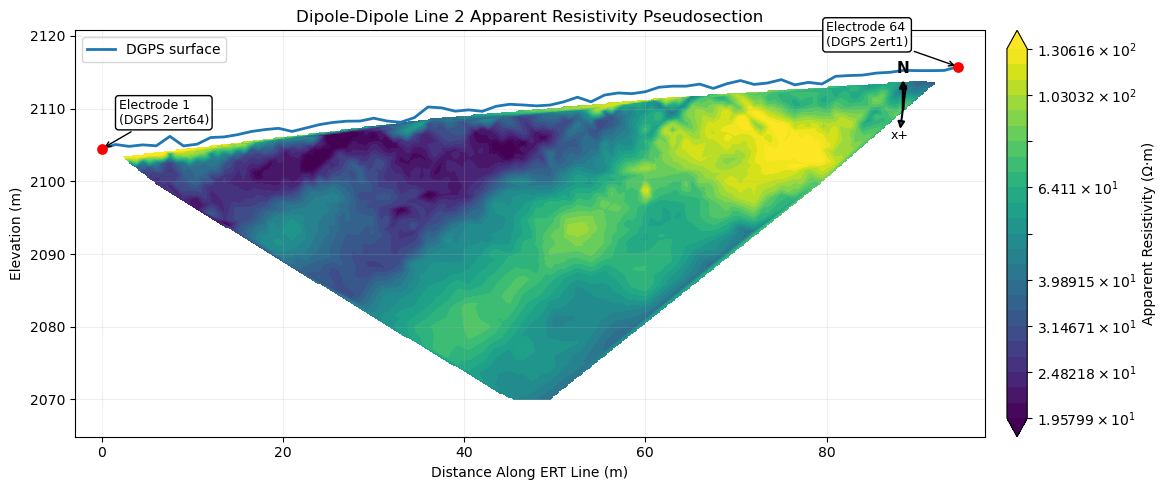

In [55]:
# -------------------------------------------
# Dipole-Dipole Line 2 with DGPS topography
# -------------------------------------------

from scipy.interpolate import griddata
from matplotlib.colors import LogNorm
import numpy as np
import matplotlib.pyplot as plt


# -------------------------------------------
# Tie dd2 to DGPS line 2 topography
# -------------------------------------------

dd2["surface_elevation_m"] = np.interp(
    dd2["distance_m"],
    dgps2["distance_m"],
    dgps2["elevation_m"]
)

dd2["ert_elevation_m"] = (
    dd2["surface_elevation_m"]
    - dd2["pseudo_depth_m"]
)


# -------------------------------------------
# Calculate bearing for line 2
# x = 0 m   -> electrode 1 -> DGPS 2ert64
# x = 94.5m -> electrode 64 -> DGPS 2ert1
# -------------------------------------------

lat1 = np.radians(dgps2.iloc[0]["Latitude"])
lon1 = np.radians(dgps2.iloc[0]["Longitude"])

lat2 = np.radians(dgps2.iloc[-1]["Latitude"])
lon2 = np.radians(dgps2.iloc[-1]["Longitude"])

dlon = lon2 - lon1

x_bearing = np.sin(dlon) * np.cos(lat2)
y_bearing = (
    np.cos(lat1) * np.sin(lat2)
    - np.sin(lat1) * np.cos(lat2) * np.cos(dlon)
)

bearing2 = (
    np.degrees(np.arctan2(x_bearing, y_bearing)) + 360
) % 360


# -------------------------------------------
# Keep only valid positive resistivity values
# -------------------------------------------

plot_df = dd2.copy()

plot_df = plot_df[
    np.isfinite(plot_df["apparent_resistivity"]) &
    np.isfinite(plot_df["distance_m"]) &
    np.isfinite(plot_df["ert_elevation_m"]) &
    (plot_df["apparent_resistivity"] > 0)
].copy()


# -------------------------------------------
# Build interpolation grid
# -------------------------------------------

x_min = dgps2["distance_m"].min()
x_max = dgps2["distance_m"].max()

y_min = plot_df["ert_elevation_m"].min()
y_max = dgps2["elevation_m"].max()

xi = np.linspace(x_min, x_max, 400)
yi = np.linspace(y_min, y_max, 250)

XI, YI = np.meshgrid(xi, yi)


# -------------------------------------------
# Interpolate apparent resistivity onto grid
# -------------------------------------------

ZI = griddata(
    (plot_df["distance_m"], plot_df["ert_elevation_m"]),
    plot_df["apparent_resistivity"],
    (XI, YI),
    method="linear"
)


# -------------------------------------------
# Mask everything above the DGPS surface
# -------------------------------------------

surface_elev = np.interp(
    xi,
    dgps2["distance_m"],
    dgps2["elevation_m"]
)

for j in range(len(xi)):
    ZI[YI[:, j] > surface_elev[j], j] = np.nan


# -------------------------------------------
# Choose contour levels
# -------------------------------------------

vmin = np.nanpercentile(plot_df["apparent_resistivity"], 2)
vmax = np.nanpercentile(plot_df["apparent_resistivity"], 98)

levels = np.geomspace(vmin, vmax, 25)


# -------------------------------------------
# Plot
# -------------------------------------------

fig, ax = plt.subplots(figsize=(12, 5))


# -------------------------------------------
# Add orientation / north indicator
# -------------------------------------------

compass = ax.inset_axes([0.86, 0.72, 0.10, 0.18])

compass.set_xlim(-1.2, 1.2)
compass.set_ylim(-1.2, 1.2)
compass.set_aspect("equal")
compass.axis("off")

# North arrow
compass.annotate(
    "",
    xy=(0, 1),
    xytext=(0, -0.15),
    arrowprops=dict(
        arrowstyle="-|>",
        linewidth=2
    )
)

compass.text(
    0,
    1.05,
    "N",
    ha="center",
    va="bottom",
    fontsize=11,
    fontweight="bold"
)

# ERT line direction
theta = np.radians(90 - bearing2)

dx = 0.8 * np.cos(theta)
dy = 0.8 * np.sin(theta)

compass.annotate(
    "",
    xy=(dx, dy),
    xytext=(-dx, -dy),
    arrowprops=dict(
        arrowstyle="-|>",
        linewidth=1.5
    )
)

compass.text(
    dx * 1.15,
    dy * 1.15,
    "x+",
    ha="center",
    va="center",
    fontsize=9
)


# -------------------------------------------
# Filled contours
# -------------------------------------------

cf = ax.contourf(
    XI,
    YI,
    ZI,
    levels=levels,
    norm=LogNorm(vmin=vmin, vmax=vmax),
    extend="both"
)


# -------------------------------------------
# DGPS surface
# -------------------------------------------

ax.plot(
    dgps2["distance_m"],
    dgps2["elevation_m"],
    linewidth=2,
    label="DGPS surface"
)



# -------------------------------------------
# Colorbar and labels
# -------------------------------------------

cbar = plt.colorbar(cf, ax=ax, pad=0.02)
cbar.set_label("Apparent Resistivity (Ω·m)")

ax.set_xlabel("Distance Along ERT Line (m)")
ax.set_ylabel("Elevation (m)")
ax.set_title("Dipole-Dipole Line 2 Apparent Resistivity Pseudosection")
ax.legend()
ax.grid(alpha=0.2)


# -------------------------------------------
# Label first and last electrodes
# -------------------------------------------

# First electrode (x = 0 m)
x1 = dgps2["distance_m"].iloc[0]
y1 = dgps2["elevation_m"].iloc[0]

ax.scatter(x1, y1, s=45, color="red", zorder=5)

ax.annotate(
    "Electrode 1\n(DGPS 2ert64)",
    xy=(x1, y1),
    xytext=(12, 18),
    textcoords="offset points",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="black"),
    arrowprops=dict(arrowstyle="->")
)


# Last electrode (x = 94.5 m)
x2 = dgps2["distance_m"].iloc[-1]
y2 = dgps2["elevation_m"].iloc[-1]

ax.scatter(x2, y2, s=45, color="red", zorder=5)

ax.annotate(
    "Electrode 64\n(DGPS 2ert1)",
    xy=(x2, y2),
    xytext=(-95, 15),
    textcoords="offset points",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="black"),
    arrowprops=dict(arrowstyle="->")
)


# -------------------------------------------
# Add a little space around the plot
# -------------------------------------------

current_ymin, current_ymax = ax.get_ylim()

ax.set_ylim(
    current_ymin - 5,
    current_ymax + 5
)

ax.set_xlim(
    -3,
    97.5
)

plt.tight_layout()

plt.show()